**G05:** Jakober, Winkler, Matzinger, Salzmann

In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from torch import nn
from torch.utils.data import DataLoader
from torchsummary import summary
from torchvision import datasets, transforms
from tqdm import tqdm

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Device is set to: {device}")

Device is set to: cuda


## Loading the data

In [3]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

### Normalizing the Data

In [4]:
loader = DataLoader(training_data, batch_size=60000, shuffle=True, num_workers=2)
X, _ = next(iter(loader))
mean, std = torch.mean(X).item(), torch.std(X).item()
print(mean, std)

0.28604060411453247 0.3530242443084717


In [5]:
batch_size = 512

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean, std)])
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean, std)])
)

train_loader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

In [6]:
## Testing the normalization
X, _ = next(iter(train_loader))
print(torch.mean(X), torch.std(X))

tensor(-0.0023) tensor(0.9969)


Mean is around 0 and STD around 1, so everything correct here

## Defining the CNN

In [7]:
class Baseline(nn.Module):
    def __init__(self, activation = F.tanh):
        super(Baseline, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding="same")
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding="same")
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding="same")
        self.conv4 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding="same")
        self.conv5 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding="same")
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(in_features=28*28*32, out_features=10)
        self.activation = activation

    def forward(self, x):
        x = self.activation(self.conv1(x))
        x = self.activation(self.conv2(x))
        x = self.activation(self.conv3(x))
        x = self.activation(self.conv4(x))
        x = self.activation(self.conv5(x))
        x = self.linear(self.flatten(x))
        return x

In [8]:
baseline = Baseline().to(device)
summary(baseline, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
            Conv2d-2           [-1, 32, 28, 28]           9,248
            Conv2d-3           [-1, 32, 28, 28]           9,248
            Conv2d-4           [-1, 32, 28, 28]           9,248
            Conv2d-5           [-1, 32, 28, 28]           9,248
           Flatten-6                [-1, 25088]               0
            Linear-7                   [-1, 10]         250,890
Total params: 288,202
Trainable params: 288,202
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 1.15
Params size (MB): 1.10
Estimated Total Size (MB): 2.25
----------------------------------------------------------------


## Training Loop

In [9]:
def run_epoch(model, dataloader, optimizer, criterion, train=True):
    """
    Runs one epoch for training or validation.
    """
    epoch_loss = 0
    correct = 0
    total_samples = len(dataloader.dataset)

    if train:
        model.train()
    else:
        model.eval()

    for X, y in tqdm(dataloader, desc=f'{"Train" if train else "Val"} Epoch', disable=True):
        X, y = X.to(device), y.to(device)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            output = model(X)
            loss = criterion(output, y)

        epoch_loss += loss.item()
        _, y_pred = torch.max(output, dim=1)
        correct += torch.sum(y_pred == y).item()

        if train:
            loss.backward()
            optimizer.step()

    avg_loss = epoch_loss / len(dataloader)
    accuracy = correct / total_samples

    return avg_loss, accuracy

def trainer(model, train_loader, val_loader, optimizer, criterion, n_epochs):
    """
    Trains and evaluates the model for n_epochs.
    """
    epoch_train_losses = []
    epoch_val_losses = []
    epoch_train_accs = []
    epoch_val_accs = []

    for epoch in range(n_epochs):

        print(f'\nEpoch {epoch+1}/{n_epochs}')
        print('----------')

        train_loss, train_acc = run_epoch(model, train_loader, optimizer, criterion, train=True)
        val_loss, val_acc = run_epoch(model, val_loader, optimizer, criterion, train=False)

        epoch_train_losses.append(train_loss)
        epoch_val_losses.append(val_loss)
        epoch_train_accs.append(train_acc)
        epoch_val_accs.append(val_acc)

        print(f'Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}\nVal Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}')

    return epoch_train_losses, epoch_val_losses, epoch_train_accs, epoch_val_accs

In [10]:
def eval(model, test_loader, criterion):
    """
    Evaluates the model on the test set.
    """
    epoch_loss = 0
    correct = 0
    y_preds = []

    model.eval()
    with torch.no_grad():
        for X_test, y_test in tqdm(test_loader):
            X_test, y_test = X_test.to(device), y_test.to(device)

            output = model(X_test)
            loss = criterion(output, y_test)
            epoch_loss += loss.item()

            _, y_pred = torch.max(output, dim=1)
            y_preds.append(y_pred.cpu())
            correct += torch.sum(y_pred == y_test).item()

        epoch_loss /= len(test_loader)
        accuracy = correct / len(test_loader.dataset)

    y_preds = torch.cat(y_preds).numpy()

    return epoch_loss, accuracy, y_preds


In [11]:
num_epochs = 10
optimizer = torch.optim.Adam(baseline.parameters())
criterion = nn.CrossEntropyLoss()

epoch_train_losses, epoch_val_losses, epoch_train_accs, epoch_val_accs = trainer(baseline, train_loader, test_loader, optimizer, criterion, num_epochs)


Epoch 1/10
----------
Train Loss: 0.5426, Train Accuracy: 0.8080
Val Loss: 0.4462, Val Accuracy: 0.8448

Epoch 2/10
----------
Train Loss: 0.3765, Train Accuracy: 0.8669
Val Loss: 0.3757, Val Accuracy: 0.8686

Epoch 3/10
----------
Train Loss: 0.3155, Train Accuracy: 0.8863
Val Loss: 0.3272, Val Accuracy: 0.8869

Epoch 4/10
----------
Train Loss: 0.2743, Train Accuracy: 0.9012
Val Loss: 0.2999, Val Accuracy: 0.8945

Epoch 5/10
----------
Train Loss: 0.2458, Train Accuracy: 0.9119
Val Loss: 0.2923, Val Accuracy: 0.8965

Epoch 6/10
----------
Train Loss: 0.2136, Train Accuracy: 0.9232
Val Loss: 0.2676, Val Accuracy: 0.9075

Epoch 7/10
----------
Train Loss: 0.1916, Train Accuracy: 0.9311
Val Loss: 0.2672, Val Accuracy: 0.9068

Epoch 8/10
----------
Train Loss: 0.1790, Train Accuracy: 0.9348
Val Loss: 0.2844, Val Accuracy: 0.9035

Epoch 9/10
----------
Train Loss: 0.1653, Train Accuracy: 0.9408
Val Loss: 0.2895, Val Accuracy: 0.9070

Epoch 10/10
----------
Train Loss: 0.1434, Train Accur

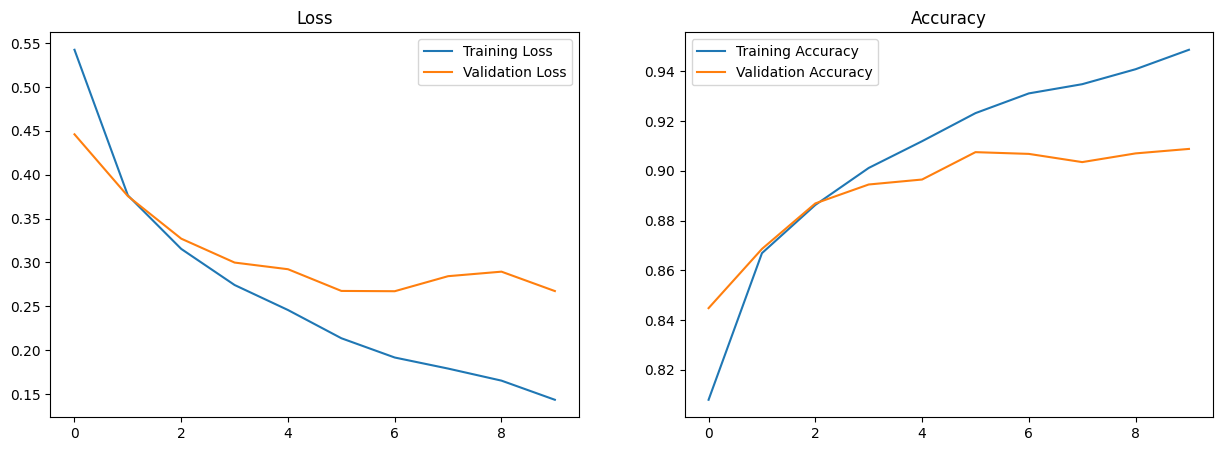

In [12]:
plt.figure(1, figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(epoch_train_losses, label='Training Loss')
plt.plot(epoch_val_losses, label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(epoch_train_accs, label='Training Accuracy')
plt.plot(epoch_val_accs, label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()
plt.show()

## Different initializations

In [13]:
def initialize_weights(model, init_type):
    for m in model.modules():
        if isinstance(m, (nn.Linear, nn.Conv2d)):
            if init_type == 'zero':
                nn.init.constant_(m.weight, 0)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif init_type == 'normal':
                nn.init.normal_(m.weight, mean=0.0, std=1.0)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif init_type == 'uniform':
                nn.init.uniform_(m.weight, a=-0.5, b=0.5)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif init_type == 'xavier':
                nn.init.xavier_uniform_(m.weight, gain=nn.init.calculate_gain('tanh'))
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif init_type == 'kaiming':
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

In [14]:
init_types = ['zero', 'normal', 'uniform', 'xavier', 'kaiming']
results = {}
num_epochs = 10

for init_type in init_types:
    baseline = Baseline(F.relu if init_type == "kaiming" else F.tanh).to(device)
    initialize_weights(baseline, init_type)

    optimizer = torch.optim.Adam(baseline.parameters())
    criterion = nn.CrossEntropyLoss()

    train_loss, val_loss, train_acc, val_acc = trainer(baseline, train_loader, test_loader, optimizer, criterion, num_epochs)

    results[init_type] = {
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_acc': train_acc,
        'val_acc': val_acc
    }


Epoch 1/10
----------
Train Loss: 2.3026, Train Accuracy: 0.0976
Val Loss: 2.3026, Val Accuracy: 0.1000

Epoch 2/10
----------
Train Loss: 2.3026, Train Accuracy: 0.0994
Val Loss: 2.3026, Val Accuracy: 0.1000

Epoch 3/10
----------
Train Loss: 2.3026, Train Accuracy: 0.0995
Val Loss: 2.3026, Val Accuracy: 0.1000

Epoch 4/10
----------
Train Loss: 2.3026, Train Accuracy: 0.0977
Val Loss: 2.3026, Val Accuracy: 0.1000

Epoch 5/10
----------
Train Loss: 2.3026, Train Accuracy: 0.0982
Val Loss: 2.3026, Val Accuracy: 0.1000

Epoch 6/10
----------
Train Loss: 2.3026, Train Accuracy: 0.0985
Val Loss: 2.3026, Val Accuracy: 0.1000

Epoch 7/10
----------
Train Loss: 2.3026, Train Accuracy: 0.1003
Val Loss: 2.3026, Val Accuracy: 0.1000

Epoch 8/10
----------
Train Loss: 2.3026, Train Accuracy: 0.0975
Val Loss: 2.3026, Val Accuracy: 0.1000

Epoch 9/10
----------
Train Loss: 2.3026, Train Accuracy: 0.0990
Val Loss: 2.3026, Val Accuracy: 0.1000

Epoch 10/10
----------
Train Loss: 2.3026, Train Accur

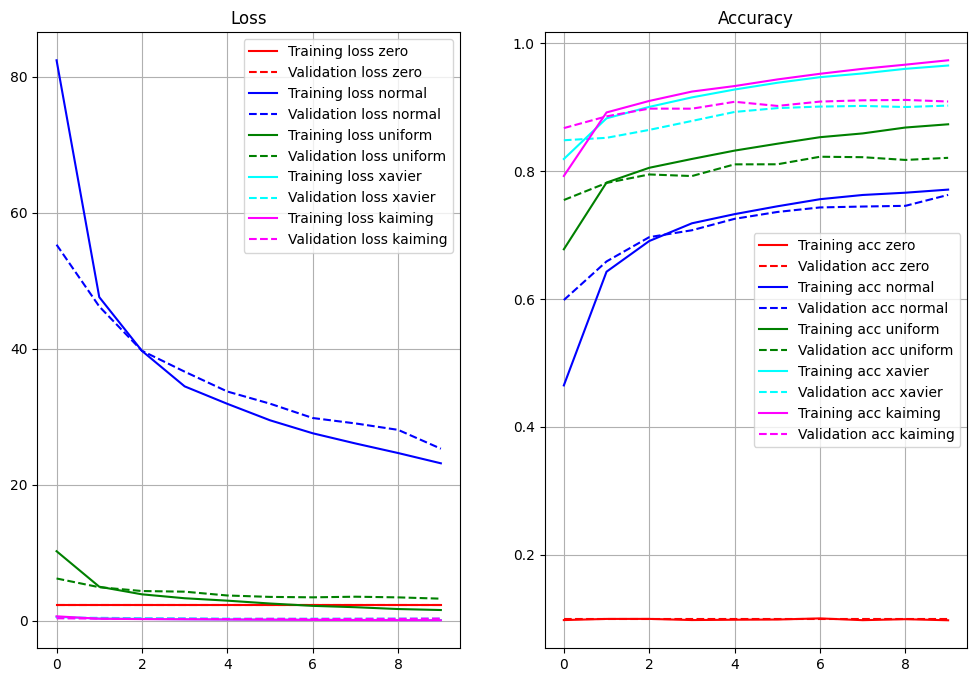

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8))
axes[0].set_title('Loss')
axes[1].set_title('Accuracy')

colors = ['red', 'blue', 'green', 'cyan', 'magenta']

for init_type, color in zip(results.keys(), colors):
    axes[0].plot(results[init_type]['train_loss'], linestyle='-', color=color, label=f'Training loss {init_type}')
    axes[0].plot(results[init_type]['val_loss'], linestyle='--', color=color, label=f'Validation loss {init_type}')
    axes[0].legend()
    axes[0].grid()
    axes[1].plot(results[init_type]['train_acc'], linestyle='-', color=color, label=f'Training acc {init_type}')
    axes[1].plot(results[init_type]['val_acc'], linestyle='--', color=color, label=f'Validation acc {init_type}')
    axes[1].legend()
    axes[1].grid()

plt.show()

## Comments

#### Zero
Acc of around 10%, so it is a random classifier. As every weight starts at the same point, every neuron learns the same and the symmetry is not broken, so the network does not learn anything.

#### Normal
Loss starts very high and accuracy low, afterward it improves, but slowly and does not reach the performance of the other initialization methods.

#### Uniform
Loss and accuracy better than normal, but not on level of Xavier and Kaiming. It is not specialized for an activation function like xavier (for tanh) and kaiming (relu)

#### Xavier
Good Loss and Good Accuracy, achieves a test-accuracy around 90%. As expected by the theory learned in class, as we use a tanh in the model and Xavier should do really well on such a model.

#### Kaiming
Loss and Accuracy slightly better than Xavier. It is specialized for ReLU and we use therefore ReLU in the model itself which explains the good performance.